# E01 — Pretrained ResNet-18 Training and Ablation Experiments

This notebook performs the official transfer-learning experiments for Part E.

It contains three experiments:

1. **main**: ImageNet pretrained weights, data augmentation, and progressive layer unfreezing.
2. **no_augmentation**: identical to `main`, except that data augmentation is disabled.
3. **head_only**: the ResNet-18 backbone remains frozen and only the final classification head is trained.

All experiments use the same training and validation manifests.

This local version does **not** save a tiny `small_test` checkpoint. The previous small test used only 64 training images, 32 validation images, and one epoch, so it was suitable only for checking the pipeline and not for final evaluation.


## Step 1 — Import dependencies and locate the project directory


In [2]:
%pip install matplotlib numpy pandas scikit-learn pillow tqdm

  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached tqdm-4.69.0-py3-none-any.whl.metadata (57 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached scipy-1.18.0-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl (9.8 MB)
Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached tqdm-4.69.0-py3-none-any.whl (676 kB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Usin

In [4]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-78.1.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 68.4 MB/s eta 0:00:38
   ---------------------------------------- 0.0/2.6 GB 67.7 MB/s eta 0:00:38
    --------------------------------------- 0.0/2.6 GB 68.8 MB/s eta 0:00:38
    --------------------------------------- 0.1/2.6 GB 68.4 MB/s eta 0:00:38
   - -------------------------------------- 0.1/2.6 GB 68.4 MB/s eta 0:00:37
   - ------------------------------

In [2]:
import csv
import json
import os
import random
import shutil
import sys
import time
from contextlib import nullcontext
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm


def find_project_root(start_path):
    """Search the current directory and its parents for the project root."""
    current = Path(start_path).resolve()

    for candidate in [current, *current.parents]:
        has_source_directory = (candidate / "src").exists()
        has_processed_data = (candidate / "data" / "processed").exists()

        if has_source_directory and has_processed_data:
            return candidate

    raise FileNotFoundError(
        "The project repository could not be found. "
        "Open this notebook from inside the repository or one of its subdirectories."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.data import create_dataloader, create_dataset


DATA_RAW_ROOT = Path(config.DATA_RAW_ROOT)
OUTPUT_ROOT = Path(config.OUTPUT_ROOT) / "pretrained"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("PyTorch version:", torch.__version__)
print("Data root:", DATA_RAW_ROOT)
print("Output root:", OUTPUT_ROOT)


Project root: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group
PyTorch version: 2.13.0+cu126
Data root: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\data\raw
Output root: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\outputs\pretrained


c:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\.venv-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: c:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\.venv-gpu\Scripts\python.exe
PyTorch: 2.13.0+cu126
CUDA build: 12.6
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Step 2 — Validate the dataset manifests

Only the training and validation sets are used during model development.

The independent test set must remain untouched until E02.


In [4]:
train_df = pd.read_csv(config.TRAIN_CSV)
val_df = pd.read_csv(config.VAL_CSV)
test_df = pd.read_csv(config.TEST_CSV)

print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

print("Training classes:", train_df["label"].nunique())
print("Validation classes:", val_df["label"].nunique())
print("Test classes:", test_df["label"].nunique())

if train_df["label"].nunique() != config.NUM_CLASSES:
    raise RuntimeError(
        "The training manifest does not contain all configured classes."
    )

if val_df["label"].nunique() != config.NUM_CLASSES:
    raise RuntimeError(
        "The validation manifest does not contain all configured classes."
    )

first_relative_path = Path(train_df.iloc[0]["file_path"])
first_image_path = DATA_RAW_ROOT / first_relative_path

print("\nFirst training image path:", first_image_path)
print("First training image exists:", first_image_path.exists())

if not first_image_path.exists():
    raise FileNotFoundError(
        f"The first training image could not be found: {first_image_path}"
    )

print("\nTraining samples per class:")
print(train_df.groupby("label").size().describe())

print("\nValidation samples per class:")
print(val_df.groupby("label").size().describe())


Training rows: 20000
Validation rows: 5000
Test rows: 5000
Training classes: 500
Validation classes: 500
Test classes: 500

First training image path: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\data\raw\train_mini\07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii\f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg
First training image exists: True

Training samples per class:
count    500.0
mean      40.0
std        0.0
min       40.0
25%       40.0
50%       40.0
75%       40.0
max       40.0
dtype: float64

Validation samples per class:
count    500.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
dtype: float64


## Step 3 — Set the random seed and select the device

CUDA is strongly recommended for the official training run.

Windows Jupyter execution uses `num_workers=0` for reliability.


In [5]:
def set_random_seed(seed):
    """Seed all random sources for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device():
    """Prefer CUDA, then Apple MPS, and otherwise use the CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


set_random_seed(config.RANDOM_SEED)
DEVICE = get_device()

# Use a larger batch on CUDA and a safer batch on CPU or MPS.
BATCH_SIZE = 32 if DEVICE.type == "cuda" else 8

# Zero workers is the safest option in Windows Jupyter and VS Code notebooks.
NUM_WORKERS = 0

print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)
print("DataLoader workers:", NUM_WORKERS)

if DEVICE.type == "cpu":
    print(
        "Warning: official ResNet-18 training on the CPU may take a long time. "
        "A CUDA GPU is strongly recommended."
    )


Device: cuda
Batch size: 32
DataLoader workers: 0


## Step 4 — Define the training and evaluation transforms

The main experiment uses augmentation during training.

Validation always uses deterministic preprocessing.


In [6]:
def create_train_transform(use_augmentation=True):
    """Create the training preprocessing pipeline."""
    image_size = config.IMG_SIZE[0]

    if not use_augmentation:
        return create_eval_transform()

    return transforms.Compose(
        [
            transforms.RandomResizedCrop(
                image_size,
                scale=(0.75, 1.0),
            ),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05,
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                config.IMG_MEAN,
                config.IMG_STD,
            ),
        ]
    )


def create_eval_transform():
    """Create the deterministic validation preprocessing pipeline."""
    image_size = config.IMG_SIZE[0]
    resize_size = int(image_size / 0.875)

    return transforms.Compose(
        [
            transforms.Resize(resize_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                config.IMG_MEAN,
                config.IMG_STD,
            ),
        ]
    )


## Step 5 — Define the pretrained ResNet-18 model

The original 1000-class ImageNet classification layer is replaced with a classifier for the project classes.

Training modes:

- `head`: train only the final fully connected layer.
- `layer4`: train the final residual stage and the classification head.
- `all`: train the complete network.


In [7]:
def set_train_mode(model, train_mode):
    """Freeze the model and enable gradients only for the selected layers."""
    valid_modes = {"head", "layer4", "all"}

    if train_mode not in valid_modes:
        raise ValueError(f"Unknown training mode: {train_mode}")

    for parameter in model.parameters():
        parameter.requires_grad = False

    if train_mode == "head":
        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    elif train_mode == "layer4":
        for parameter in model.layer4.parameters():
            parameter.requires_grad = True

        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    elif train_mode == "all":
        for parameter in model.parameters():
            parameter.requires_grad = True

    return model


def set_frozen_batchnorm_eval(model):
    """Keep frozen BatchNorm layers in evaluation mode."""
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            is_trainable = any(
                parameter.requires_grad
                for parameter in module.parameters()
            )

            if not is_trainable:
                module.eval()


def count_trainable_parameters(model):
    """Count model parameters that currently receive gradients."""
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def create_pretrained_resnet18(
    use_pretrained=True,
    train_mode="head",
):
    """Create ResNet-18 and configure its trainable layers."""
    weights = (
        ResNet18_Weights.DEFAULT
        if use_pretrained
        else None
    )

    model = resnet18(weights=weights)
    model.fc = nn.Linear(
        model.fc.in_features,
        config.NUM_CLASSES,
    )

    return set_train_mode(model, train_mode)


## Step 6 — Run a model architecture check


In [8]:
smoke_model = create_pretrained_resnet18(
    use_pretrained=False,
    train_mode="head",
)

smoke_input = torch.randn(
    2,
    3,
    config.IMG_SIZE[0],
    config.IMG_SIZE[1],
)

smoke_output = smoke_model(smoke_input)

print("Output shape:", tuple(smoke_output.shape))
print("Expected shape:", (2, config.NUM_CLASSES))
print(
    "Trainable parameters in head mode:",
    f"{count_trainable_parameters(smoke_model):,}",
)

assert smoke_output.shape == (2, config.NUM_CLASSES)

del smoke_model
del smoke_input
del smoke_output


Output shape: (2, 500)
Expected shape: (2, 500)
Trainable parameters in head mode: 256,500


## Step 7 — Define training and validation metrics


In [9]:
def calculate_topk(logits, labels, topk=(1, 5)):
    """Count correct predictions for each requested top-k value."""
    max_k = min(max(topk), logits.shape[1])
    predictions = logits.topk(max_k, dim=1).indices
    correct = predictions.eq(labels.view(-1, 1))

    results = {}

    for k in topk:
        current_k = min(k, logits.shape[1])
        results[k] = (
            correct[:, :current_k]
            .any(dim=1)
            .sum()
            .item()
        )

    return results


def autocast_context(device, enabled):
    """Return a CUDA autocast context or a no-op context."""
    if enabled and device.type == "cuda":
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )

    return nullcontext()


## Step 8 — Define one training epoch and one validation epoch


In [10]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    scaler,
    device,
    use_amp,
    description,
):
    """Train the model for one complete epoch."""
    model.train()
    set_frozen_batchnorm_eval(model)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress = tqdm(
        dataloader,
        desc=description,
        leave=False,
    )

    for images, labels in progress:
        images = images.to(
            device,
            non_blocking=True,
        )
        labels = labels.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with autocast_context(device, use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        current_batch_size = labels.shape[0]

        total_loss += loss.item() * current_batch_size
        total_correct += (
            logits.argmax(dim=1) == labels
        ).sum().item()
        total_samples += current_batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    if total_samples == 0:
        raise RuntimeError("The training DataLoader produced no samples.")

    return {
        "loss": total_loss / total_samples,
        "top1": total_correct / total_samples,
    }


def validate_one_epoch(
    model,
    dataloader,
    criterion,
    device,
    use_amp,
    description,
):
    """Evaluate the model on the complete validation set."""
    model.eval()

    total_loss = 0.0
    total_top1 = 0
    total_top5 = 0
    total_samples = 0

    all_labels = []
    all_predictions = []

    with torch.inference_mode():
        for images, labels in tqdm(
            dataloader,
            desc=description,
            leave=False,
        ):
            images = images.to(
                device,
                non_blocking=True,
            )
            labels = labels.to(
                device,
                non_blocking=True,
            )

            with autocast_context(device, use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

            topk_results = calculate_topk(
                logits,
                labels,
            )
            predictions = logits.argmax(dim=1)
            current_batch_size = labels.shape[0]

            total_loss += loss.item() * current_batch_size
            total_top1 += topk_results[1]
            total_top5 += topk_results[5]
            total_samples += current_batch_size

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(
                predictions.cpu().tolist()
            )

    if total_samples == 0:
        raise RuntimeError("The validation DataLoader produced no samples.")

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        labels=list(range(config.NUM_CLASSES)),
        average="macro",
        zero_division=0,
    )

    return {
        "loss": total_loss / total_samples,
        "top1": total_top1 / total_samples,
        "top5": total_top5 / total_samples,
        "macro_f1": macro_f1,
    }


## Step 9 — Define checkpointing and the complete staged training loop

The best checkpoint is selected using validation Top-1 accuracy.

The test set is not used for checkpoint selection.


In [11]:
def save_history(history, output_path):
    """Save all completed epoch records to CSV."""
    if not history:
        return

    with Path(output_path).open(
        "w",
        newline="",
        encoding="utf-8",
    ) as file:
        writer = csv.DictWriter(
            file,
            fieldnames=list(history[0].keys()),
        )
        writer.writeheader()
        writer.writerows(history)


def save_checkpoint(
    checkpoint_path,
    model,
    optimizer,
    scheduler,
    stage_index,
    stage_epoch,
    global_epoch,
    best_val_top1,
    history,
    run_config,
):
    """Save all information required to resume training."""
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "stage_index": stage_index,
        "stage_epoch": stage_epoch,
        "global_epoch": global_epoch,
        "best_val_top1": best_val_top1,
        "history": history,
        "run_config": run_config,
    }

    torch.save(checkpoint, checkpoint_path)


def fit_transfer_model(
    model,
    train_loader,
    val_loader,
    stages,
    output_dir,
    run_config,
    device,
    resume=False,
    label_smoothing=0.1,
    weight_decay=1e-4,
):
    """Run staged transfer learning with optional checkpoint resumption."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(
        label_smoothing=label_smoothing,
    )

    use_amp = device.type == "cuda"

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=use_amp,
    )

    history = []
    best_val_top1 = -1.0
    global_epoch = 0

    resume_stage_index = 0
    resume_stage_epoch = 0
    resume_optimizer_state = None
    resume_scheduler_state = None

    last_checkpoint_path = (
        output_dir / "last_checkpoint.pth"
    )
    best_checkpoint_path = (
        output_dir / "best_checkpoint.pth"
    )

    if resume and last_checkpoint_path.exists():
        checkpoint = torch.load(
            last_checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        history = checkpoint.get("history", [])
        best_val_top1 = checkpoint.get(
            "best_val_top1",
            -1.0,
        )
        global_epoch = checkpoint.get(
            "global_epoch",
            0,
        )

        resume_stage_index = checkpoint.get(
            "stage_index",
            0,
        )
        resume_stage_epoch = (
            checkpoint.get("stage_epoch", 0) + 1
        )

        resume_optimizer_state = checkpoint.get(
            "optimizer_state_dict"
        )
        resume_scheduler_state = checkpoint.get(
            "scheduler_state_dict"
        )

        print(
            "Resuming from "
            f"stage {resume_stage_index + 1}, "
            f"stage epoch {resume_stage_epoch + 1}."
        )

    with (output_dir / "run_config.json").open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            run_config,
            file,
            indent=2,
        )

    for stage_index, stage in enumerate(stages):
        if stage_index < resume_stage_index:
            continue

        set_train_mode(
            model,
            stage["train_mode"],
        )

        trainable_parameters = [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ]

        optimizer = AdamW(
            trainable_parameters,
            lr=stage["learning_rate"],
            weight_decay=weight_decay,
        )

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=max(stage["epochs"], 1),
        )

        start_epoch = 0

        if (
            stage_index == resume_stage_index
            and resume_stage_epoch > 0
        ):
            start_epoch = resume_stage_epoch

            if resume_optimizer_state is not None:
                optimizer.load_state_dict(
                    resume_optimizer_state
                )

            if resume_scheduler_state is not None:
                scheduler.load_state_dict(
                    resume_scheduler_state
                )

        print("\n" + "=" * 70)
        print(
            f"Stage {stage_index + 1}: "
            f"{stage['name']}"
        )
        print(
            "Training mode:",
            stage["train_mode"],
        )
        print(
            "Trainable parameters:",
            f"{count_trainable_parameters(model):,}",
        )
        print(
            "Stage epochs:",
            stage["epochs"],
        )
        print(
            "Initial learning rate:",
            stage["learning_rate"],
        )
        print("=" * 70)

        for stage_epoch in range(
            start_epoch,
            stage["epochs"],
        ):
            epoch_start = time.perf_counter()
            next_global_epoch = global_epoch + 1

            train_metrics = train_one_epoch(
                model=model,
                dataloader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                scaler=scaler,
                device=device,
                use_amp=use_amp,
                description=(
                    f"Train epoch {next_global_epoch}"
                ),
            )

            val_metrics = validate_one_epoch(
                model=model,
                dataloader=val_loader,
                criterion=criterion,
                device=device,
                use_amp=use_amp,
                description=(
                    f"Validate epoch {next_global_epoch}"
                ),
            )

            current_learning_rate = (
                optimizer.param_groups[0]["lr"]
            )

            scheduler.step()
            global_epoch += 1

            epoch_seconds = (
                time.perf_counter() - epoch_start
            )

            row = {
                "global_epoch": global_epoch,
                "stage": stage["name"],
                "stage_epoch": stage_epoch + 1,
                "learning_rate": current_learning_rate,
                "train_loss": train_metrics["loss"],
                "train_top1": train_metrics["top1"],
                "val_loss": val_metrics["loss"],
                "val_top1": val_metrics["top1"],
                "val_top5": val_metrics["top5"],
                "val_macro_f1": val_metrics["macro_f1"],
                "epoch_seconds": epoch_seconds,
            }

            history.append(row)

            save_history(
                history,
                output_dir / "history.csv",
            )

            if val_metrics["top1"] > best_val_top1:
                best_val_top1 = val_metrics["top1"]

                save_checkpoint(
                    best_checkpoint_path,
                    model,
                    optimizer,
                    scheduler,
                    stage_index,
                    stage_epoch,
                    global_epoch,
                    best_val_top1,
                    history,
                    run_config,
                )

                print(
                    "Saved a new best checkpoint "
                    f"with validation Top-1 "
                    f"{best_val_top1:.4f}."
                )

            save_checkpoint(
                last_checkpoint_path,
                model,
                optimizer,
                scheduler,
                stage_index,
                stage_epoch,
                global_epoch,
                best_val_top1,
                history,
                run_config,
            )

            print(
                f"Epoch {global_epoch:02d} | "
                f"train loss {train_metrics['loss']:.4f} | "
                f"train Top-1 {train_metrics['top1']:.4f} | "
                f"validation loss {val_metrics['loss']:.4f} | "
                f"validation Top-1 {val_metrics['top1']:.4f} | "
                f"validation Top-5 {val_metrics['top5']:.4f} | "
                f"validation Macro-F1 {val_metrics['macro_f1']:.4f} | "
                f"{epoch_seconds:.1f} seconds"
            )

        resume_stage_epoch = 0
        resume_optimizer_state = None
        resume_scheduler_state = None

    return history


## Step 10 — Define the official experiments

The `main` and `no_augmentation` experiments use the same 12-epoch staged schedule.

The `head_only` experiment also receives 12 epochs for a fair comparison.


In [12]:
EXPERIMENTS = {
    "main": {
        "use_augmentation": True,
        "stages": [
            {
                "name": "head",
                "train_mode": "head",
                "epochs": 2,
                "learning_rate": 1e-3,
            },
            {
                "name": "layer4",
                "train_mode": "layer4",
                "epochs": 6,
                "learning_rate": 3e-4,
            },
            {
                "name": "all",
                "train_mode": "all",
                "epochs": 4,
                "learning_rate": 1e-4,
            },
        ],
    },
    "no_augmentation": {
        "use_augmentation": False,
        "stages": [
            {
                "name": "head",
                "train_mode": "head",
                "epochs": 2,
                "learning_rate": 1e-3,
            },
            {
                "name": "layer4",
                "train_mode": "layer4",
                "epochs": 6,
                "learning_rate": 3e-4,
            },
            {
                "name": "all",
                "train_mode": "all",
                "epochs": 4,
                "learning_rate": 1e-4,
            },
        ],
    },
    "head_only": {
        "use_augmentation": True,
        "stages": [
            {
                "name": "head",
                "train_mode": "head",
                "epochs": 12,
                "learning_rate": 1e-3,
            },
        ],
    },
}


## Step 11 — Build full training and validation DataLoaders

No training or validation limits are applied here.

The complete manifests are always used.


In [13]:
def build_dataloaders(experiment_name):
    """Build full train and validation DataLoaders for one experiment."""
    if experiment_name not in EXPERIMENTS:
        raise ValueError(
            f"Unknown experiment: {experiment_name}"
        )

    experiment = EXPERIMENTS[experiment_name]

    train_dataset = create_dataset(
        "train",
        image_root=config.DATA_RAW_ROOT,
        transform=create_train_transform(
            experiment["use_augmentation"]
        ),
    )

    val_dataset = create_dataset(
        "val",
        image_root=config.DATA_RAW_ROOT,
        transform=create_eval_transform(),
    )

    if len(train_dataset) != len(train_df):
        raise RuntimeError(
            "The training dataset length does not match train.csv."
        )

    if len(val_dataset) != len(val_df):
        raise RuntimeError(
            "The validation dataset length does not match val.csv."
        )

    train_loader = create_dataloader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
    )

    val_loader = create_dataloader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
    )

    print(
        f"{experiment_name} training images:",
        len(train_dataset),
    )
    print(
        f"{experiment_name} validation images:",
        len(val_dataset),
    )
    print(
        f"{experiment_name} training batches:",
        len(train_loader),
    )
    print(
        f"{experiment_name} validation batches:",
        len(val_loader),
    )

    return train_loader, val_loader


## Step 12 — Optional one-batch pipeline check

This check performs one forward and backward pass but does not save a checkpoint.

It cannot be confused with an official trained model.


In [14]:
RUN_ONE_BATCH_CHECK = False

if RUN_ONE_BATCH_CHECK:
    check_train_loader, _ = build_dataloaders("main")
    check_model = create_pretrained_resnet18(
        use_pretrained=True,
        train_mode="head",
    ).to(DEVICE)

    check_optimizer = AdamW(
        [
            parameter
            for parameter in check_model.parameters()
            if parameter.requires_grad
        ],
        lr=1e-3,
    )

    check_criterion = nn.CrossEntropyLoss()

    check_images, check_labels = next(
        iter(check_train_loader)
    )

    check_images = check_images.to(DEVICE)
    check_labels = check_labels.to(DEVICE)

    check_optimizer.zero_grad(set_to_none=True)
    check_logits = check_model(check_images)
    check_loss = check_criterion(
        check_logits,
        check_labels,
    )
    check_loss.backward()
    check_optimizer.step()

    print("One-batch loss:", float(check_loss.item()))
    print("One-batch pipeline check completed.")

    del check_model
    del check_optimizer
    del check_images
    del check_labels
    del check_logits


## Step 13 — Define the official experiment runner


In [15]:
def run_experiment(
    experiment_name,
    resume=False,
):
    """Train one official experiment on the complete dataset."""
    if experiment_name not in EXPERIMENTS:
        raise ValueError(
            f"Unknown experiment: {experiment_name}"
        )

    set_random_seed(config.RANDOM_SEED)

    experiment = EXPERIMENTS[experiment_name]
    output_dir = OUTPUT_ROOT / experiment_name
    last_checkpoint_path = (
        output_dir / "last_checkpoint.pth"
    )

    train_loader, val_loader = (
        build_dataloaders(experiment_name)
    )

    use_pretrained = not (
        resume and last_checkpoint_path.exists()
    )

    model = create_pretrained_resnet18(
        use_pretrained=use_pretrained,
        train_mode="head",
    )

    run_config = {
        "experiment": experiment_name,
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "random_seed": config.RANDOM_SEED,
        "num_classes": config.NUM_CLASSES,
        "image_size": list(config.IMG_SIZE),
        "train_images": len(train_df),
        "validation_images": len(val_df),
        "use_augmentation": experiment[
            "use_augmentation"
        ],
        "stages": experiment["stages"],
        "device": str(DEVICE),
        "torch_version": torch.__version__,
    }

    print("\nOfficial experiment configuration:")
    print(json.dumps(run_config, indent=2))

    return fit_transfer_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        stages=experiment["stages"],
        output_dir=output_dir,
        run_config=run_config,
        device=DEVICE,
        resume=resume,
    )


In [16]:
import sys
import torch

print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
    )

Python executable: c:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\.venv-gpu\Scripts\python.exe
PyTorch version: 2.13.0+cu126
PyTorch CUDA build: 12.6
CUDA available: True
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU
GPU memory: 8.00 GB


## Step 14 — Train the official main model

For a new full training run:

```python
RUN_MAIN_TRAINING = True
RESUME_MAIN_TRAINING = False
```

If the process is interrupted after at least one checkpoint has been saved, change only:

```python
RESUME_MAIN_TRAINING = True
```

The official checkpoint will be saved under:

```text
outputs/pretrained/main/best_checkpoint.pth
```


In [17]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. The training has been stopped "
        "to prevent accidental CPU execution."
    )

DEVICE = torch.device("cuda")

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
)

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU memory: 8.00 GB


In [18]:
RUN_MAIN_TRAINING = True
RESUME_MAIN_TRAINING = False

if RUN_MAIN_TRAINING:
    main_history = run_experiment(
        experiment_name="main",
        resume=RESUME_MAIN_TRAINING,
    )


main training images: 20000
main validation images: 5000
main training batches: 625
main validation batches: 157

Official experiment configuration:
{
  "experiment": "main",
  "batch_size": 32,
  "num_workers": 0,
  "random_seed": 56,
  "num_classes": 500,
  "image_size": [
    224,
    224
  ],
  "train_images": 20000,
  "validation_images": 5000,
  "use_augmentation": true,
  "stages": [
    {
      "name": "head",
      "train_mode": "head",
      "epochs": 2,
      "learning_rate": 0.001
    },
    {
      "name": "layer4",
      "train_mode": "layer4",
      "epochs": 6,
      "learning_rate": 0.0003
    },
    {
      "name": "all",
      "train_mode": "all",
      "epochs": 4,
      "learning_rate": 0.0001
    }
  ],
  "device": "cuda",
  "torch_version": "2.13.0+cu126"
}

Stage 1: head
Training mode: head
Trainable parameters: 256,500
Stage epochs: 2
Initial learning rate: 0.001


Saved a new best checkpoint with validation Top-1 0.3500.
Epoch 01 | train loss 4.8352 | train Top-1 0.1660 | validation loss 3.6830 | validation Top-1 0.3500 | validation Top-5 0.5976 | validation Macro-F1 0.3196 | 183.3 seconds


Saved a new best checkpoint with validation Top-1 0.4348.
Epoch 02 | train loss 3.4973 | train Top-1 0.4146 | validation loss 3.3309 | validation Top-1 0.4348 | validation Top-5 0.6820 | validation Macro-F1 0.4129 | 160.1 seconds

Stage 2: layer4
Training mode: layer4
Trainable parameters: 8,650,228
Stage epochs: 6
Initial learning rate: 0.0003


Saved a new best checkpoint with validation Top-1 0.5014.
Epoch 03 | train loss 3.1541 | train Top-1 0.4502 | validation loss 2.9144 | validation Top-1 0.5014 | validation Top-5 0.7706 | validation Macro-F1 0.4889 | 166.2 seconds


Saved a new best checkpoint with validation Top-1 0.5482.
Epoch 04 | train loss 2.6109 | train Top-1 0.5902 | validation loss 2.7814 | validation Top-1 0.5482 | validation Top-5 0.7938 | validation Macro-F1 0.5405 | 153.7 seconds


...

Saved a new best checkpoint with validation Top-1 0.6276.
Epoch 08 | train loss 1.6261 | train Top-1 0.8966 | validation loss 2.4767 | validation Top-1 0.6276 | validation Top-5 0.8440 | validation Macro-F1 0.6213 | 154.4 seconds

Stage 3: all
Training mode: all
Trainable parameters: 11,433,012
Stage epochs: 4
Initial learning rate: 0.0001


Epoch 09 | train loss 1.8293 | train Top-1 0.8249 | validation loss 2.5900 | validation Top-1 0.5958 | validation Top-5 0.8232 | validation Macro-F1 0.5916 | 165.4 seconds


Epoch 10 | train loss 1.6585 | train Top-1 0.8816 | validation loss 2.5362 | validation Top-1 0.6138 | validation Top-5 0.8324 | validation Macro-F1 0.6079 | 166.2 seconds


Epoch 11 | train loss 1.5064 | train Top-1 0.9280 | validation loss 2.4774 | validation Top-1 0.6254 | validation Top-5 0.8378 | validation Macro-F1 0.6179 | 166.2 seconds


Saved a new best checkpoint with validation Top-1 0.6310.
Epoch 12 | train loss 1.4068 | train Top-1 0.9567 | validation loss 2.4515 | validation Top-1 0.6310 | validation Top-5 0.8472 | validation Macro-F1 0.6254 | 166.2 seconds


## Step 15 — Train the no-augmentation ablation experiment

Run this only after the main model has finished.


In [19]:
RUN_NO_AUGMENTATION = False
RESUME_NO_AUGMENTATION = False

if RUN_NO_AUGMENTATION:
    no_augmentation_history = run_experiment(
        experiment_name="no_augmentation",
        resume=RESUME_NO_AUGMENTATION,
    )


## Step 16 — Train the head-only ablation experiment

Run this only after the main model has finished.


In [20]:
RUN_HEAD_ONLY = False
RESUME_HEAD_ONLY = False

if RUN_HEAD_ONLY:
    head_only_history = run_experiment(
        experiment_name="head_only",
        resume=RESUME_HEAD_ONLY,
    )


## Step 17 — Inspect training curves


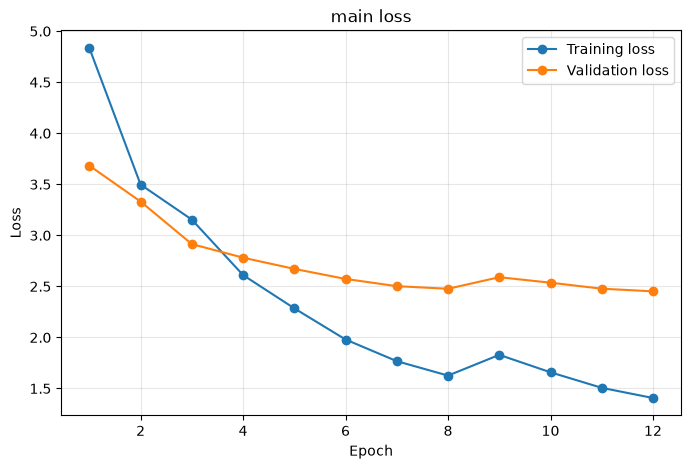

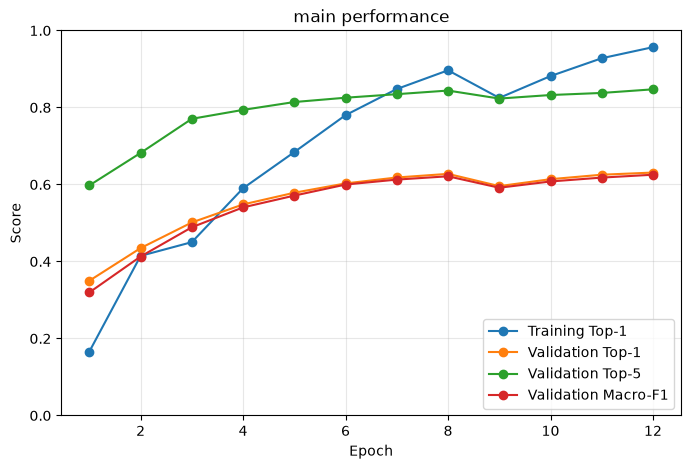

In [21]:
def plot_history(experiment_name):
    """Plot loss and performance curves for one experiment."""
    history_path = (
        OUTPUT_ROOT
        / experiment_name
        / "history.csv"
    )

    if not history_path.exists():
        print("History file not found:", history_path)
        return

    history_df = pd.read_csv(history_path)

    plt.figure(figsize=(8, 5))
    plt.plot(
        history_df["global_epoch"],
        history_df["train_loss"],
        marker="o",
        label="Training loss",
    )
    plt.plot(
        history_df["global_epoch"],
        history_df["val_loss"],
        marker="o",
        label="Validation loss",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{experiment_name} loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(
        history_df["global_epoch"],
        history_df["train_top1"],
        marker="o",
        label="Training Top-1",
    )
    plt.plot(
        history_df["global_epoch"],
        history_df["val_top1"],
        marker="o",
        label="Validation Top-1",
    )
    plt.plot(
        history_df["global_epoch"],
        history_df["val_top5"],
        marker="o",
        label="Validation Top-5",
    )
    plt.plot(
        history_df["global_epoch"],
        history_df["val_macro_f1"],
        marker="o",
        label="Validation Macro-F1",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{experiment_name} performance")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    plt.close()


plot_history("main")
